In [1]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import shap
import joblib
import matplotlib.pyplot as plt

In [ ]:
# reading in data and splitting by region
data = pd.read_csv("final_output_with_2012.csv")

ha = data[data['region'] == "Horn of Africa"]
oc = data[data['region'] == "Oceania"]
ar = data[data['region'] == "Arctic"]
sa = data[data['region'] == "South America"]


#dropping non-feature columns
ha = ha.drop(columns=['year', 'source_file', 'event_id', 'date', 'country', 'region',
                                                            'Location', 'latitude', 'longitude', 'loc_accuracy', 'Actor1', 'Actor2',
                                                            'ViolenceScore_Explanation', 'Explanation', 'Summary', 'IncomeClass_WGI'])
oc = oc.drop(columns=['year', 'source_file', 'event_id', 'date', 'country', 'region',
                                                            'Location', 'latitude', 'longitude', 'loc_accuracy', 'Actor1', 'Actor2',
                                                            'ViolenceScore_Explanation', 'Explanation', 'Summary', 'IncomeClass_WGI'])
ar = ar.drop(columns=['year', 'source_file', 'event_id', 'date', 'country', 'region',
                                                            'Location', 'latitude', 'longitude', 'loc_accuracy', 'Actor1', 'Actor2',
                                                            'ViolenceScore_Explanation', 'Explanation', 'Summary', 'IncomeClass_WGI'])
sa = sa.drop(columns=['year', 'source_file', 'event_id', 'date', 'country', 'region',
                                                            'Location', 'latitude', 'longitude', 'loc_accuracy', 'Actor1', 'Actor2',
                                                            'ViolenceScore_Explanation', 'Explanation', 'Summary', 'IncomeClass_WGI'])


In [ ]:
# for each region - if a feature column has over 25% nans, remove the column. if the column has less than 25% nans, remove the records with nans. Then, split into x and y data
hamask = (ha.isna().sum() / len(ha)) <= 0.25
hakept = ha.columns[hamask]
hax = ha[hakept].dropna()
hay = hax['violence_score']
hax.drop(columns = 'violence_score', inplace=True)

ocmask = (oc.isna().sum() / len(oc)) <= 0.25
ockept = oc.columns[ocmask]
ocx = oc[ockept].dropna()
ocy = ocx['violence_score']
ocx.drop(columns = 'violence_score', inplace=True)


armask = (ar.isna().sum() / len(ar)) <= 0.25
arkept = ar.columns[armask]
arx = ar[arkept].dropna()
ary = arx['violence_score']
arx.drop(columns = 'violence_score', inplace=True)


samask = (sa.isna().sum() / len(sa)) <= 0.25
sakept = sa.columns[samask]
sax = sa[sakept].dropna()
say = sax['violence_score']
sax.drop(columns = 'violence_score', inplace=True)

In [ ]:
# train-test split (85:15)
haX_train, haX_test, hay_train, hay_test = train_test_split(hax, hay, test_size=0.15, stratify=hay, random_state=993)
ocX_train, ocX_test, ocy_train, ocy_test = train_test_split(ocx, ocy, test_size=0.15, stratify=ocy, random_state=993)
arX_train, arX_test, ary_train, ary_test = train_test_split(arx, ary, test_size=0.15, stratify=ary, random_state=993)
saX_train, saX_test, say_train, say_test = train_test_split(sax, say, test_size=0.15, stratify=say, random_state=993)

In [ ]:
# pipeline and parameter grid for the all regions

pipeline = Pipeline([
    ("smote", SMOTE(random_state=993)),
    ("rf", RandomForestClassifier(random_state=993))
])
param_grid = {
    "smote__sampling_strategy": ["minority", "not majority", "all", "auto"],
    "smote__k_neighbors": [1,2,3],

    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 2, 5, 10],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [3, 4, 5],
    "rf__max_features": ["sqrt", "log2"],
    "rf__bootstrap": [True]
}

# GridSearch and K-fold Cross Validation (small k value to encompass low violence=3, and more repeats to account for low number of records)
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=993
)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",  
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

In [7]:
# Horn of Africa
search.fit(haX_train, hay_train)
ha_best_model = search.best_estimator_
ha_rf = ha_best_model.named_steps["rf"]

# saving gridsearch and model
joblib.dump(search, "ha_search.joblib")
joblib.dump(ha_rf, "ha_rf.joblib")

Fitting 25 folds for each of 1728 candidates, totalling 43200 fits


['ha_rf.joblib']

In [14]:
# Horn of Africa model evaluation

ha_search = joblib.load("ha_search.joblib")
ha_rf = joblib.load("ha_rf.joblib")

print(ha_search.best_params_)
print(ha_search.best_score_)
y_pred = ha_rf.predict(haX_test)
y_prob = ha_rf.predict_proba(haX_test)

print(classification_report(hay_test, y_pred))
print("ROC AUC:", roc_auc_score(hay_test, y_prob, multi_class="ovr", average="weighted"))

{'rf__bootstrap': True, 'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 2, 'rf__n_estimators': 200, 'smote__k_neighbors': 1, 'smote__sampling_strategy': 'minority'}
0.5516585365853659
              precision    recall  f1-score   support

           1       0.81      0.74      0.78        35
           2       0.71      0.69      0.70        36
           3       0.33      0.43      0.38        14

    accuracy                           0.67        85
   macro avg       0.62      0.62      0.62        85
weighted avg       0.69      0.67      0.68        85

ROC AUC: 0.8306666892108955


In [17]:
# Oceania
search.fit(ocX_train, ocy_train)
oc_best_model = search.best_estimator_
oc_rf = oc_best_model.named_steps["rf"]

# saving gridsearch and model
joblib.dump(search, "oc_search.joblib")
joblib.dump(oc_rf, "oc_rf.joblib")

Fitting 25 folds for each of 1728 candidates, totalling 43200 fits


['oc_rf.joblib']

In [18]:
# Oceania model evaluation

#uncomment these lines to load saved models
oc_search = joblib.load("oc_search.joblib")
oc_rf = joblib.load("oc_rf.joblib")

print(oc_search.best_params_)
print(oc_search.best_score_)
y_pred = oc_rf.predict(ocX_test)
y_prob = oc_rf.predict_proba(ocX_test)

print(classification_report(ocy_test, y_pred))
print("ROC AUC:", roc_auc_score(ocy_test, y_prob, multi_class="ovr", average="weighted"))


{'rf__bootstrap': True, 'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 100, 'smote__k_neighbors': 3, 'smote__sampling_strategy': 'not majority'}
0.49753968253968245
              precision    recall  f1-score   support

           1       0.62      0.71      0.67         7
           2       0.50      0.50      0.50         6
           3       0.00      0.00      0.00         1

    accuracy                           0.57        14
   macro avg       0.38      0.40      0.39        14
weighted avg       0.53      0.57      0.55        14

ROC AUC: 0.6191130298273155


c:\Users\katie\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\katie\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\katie\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
# Arctic
search.fit(arX_train, ary_train)
ar_best_model = search.best_estimator_
ar_rf = ar_best_model.named_steps["rf"]

# saving gridsearch and model
joblib.dump(search, "ar_search.joblib")
joblib.dump(ar_rf, "ar_rf.joblib")

Fitting 25 folds for each of 1728 candidates, totalling 43200 fits


['ar_rf.joblib']

In [26]:
# Arctic Model Eval

ar_search = joblib.load("ar_search.joblib")
ar_rf = joblib.load("ar_rf.joblib")

print(ar_search.best_params_)
print(ar_search.best_score_)
y_pred = ar_rf.predict(arX_test)
y_prob = ar_rf.predict_proba(arX_test)

print(classification_report(ary_test, y_pred))
print("ROC AUC:", roc_auc_score(ary_test, y_prob[:, 1]))

{'rf__bootstrap': True, 'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 200, 'smote__k_neighbors': 3, 'smote__sampling_strategy': 'minority'}
0.7979999999999999
              precision    recall  f1-score   support

           1       0.93      0.68      0.79        19
           2       0.40      0.80      0.53         5

    accuracy                           0.71        24
   macro avg       0.66      0.74      0.66        24
weighted avg       0.82      0.71      0.73        24

ROC AUC: 0.8631578947368421


In [15]:
# South America
search.fit(saX_train, say_train)
sa_best_model = search.best_estimator_
sa_rf = sa_best_model.named_steps["rf"]

# saving gridsearch and model
joblib.dump(search, "sa_search.joblib")
joblib.dump(sa_rf, "sa_rf.joblib")

Fitting 25 folds for each of 1728 candidates, totalling 43200 fits


['sa_rf.joblib']

In [16]:
# South America Model Eval

sa_search = joblib.load("sa_search.joblib")
sa_rf = joblib.load("sa_rf.joblib")

print(sa_search.best_params_)
print(sa_search.best_score_)
y_pred = sa_rf.predict(saX_test)
y_prob = sa_rf.predict_proba(saX_test)

print(classification_report(say_test, y_pred))
print("ROC AUC:", roc_auc_score(say_test, y_prob, multi_class="ovr", average="weighted"))

{'rf__bootstrap': True, 'rf__max_depth': 2, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 200, 'smote__k_neighbors': 1, 'smote__sampling_strategy': 'not majority'}
0.6171428571428571
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.75      0.50      0.60         6
           3       0.33      1.00      0.50         1

    accuracy                           0.50         8
   macro avg       0.36      0.50      0.37         8
weighted avg       0.60      0.50      0.51         8

ROC AUC: 0.7142857142857144


In [29]:
#computing SHAP Values
ha_explainer = shap.TreeExplainer(ha_rf)
oc_explainer = shap.TreeExplainer(oc_rf)
ar_explainer = shap.TreeExplainer(ar_rf)
sa_explainer = shap.TreeExplainer(sa_rf)

ha_shap_values = ha_explainer(haX_test)
oc_shap_values = oc_explainer(ocX_test)
ar_shap_values = ar_explainer(arX_test)
sa_shap_values = sa_explainer(saX_test)

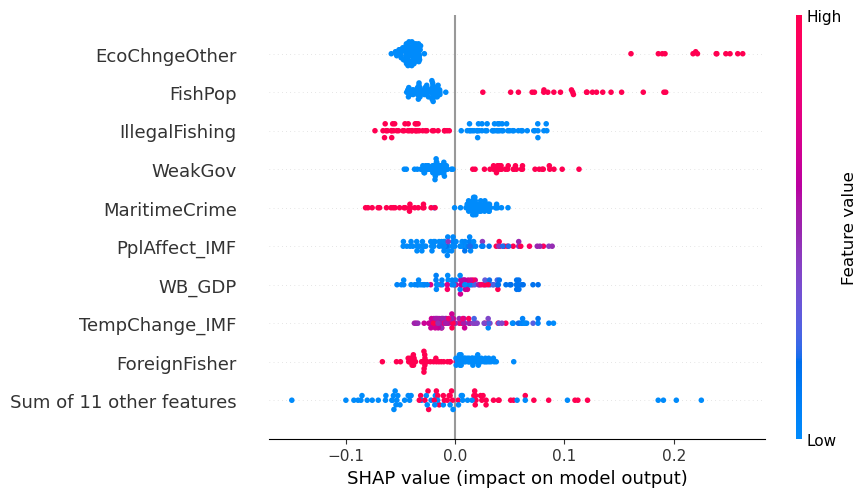

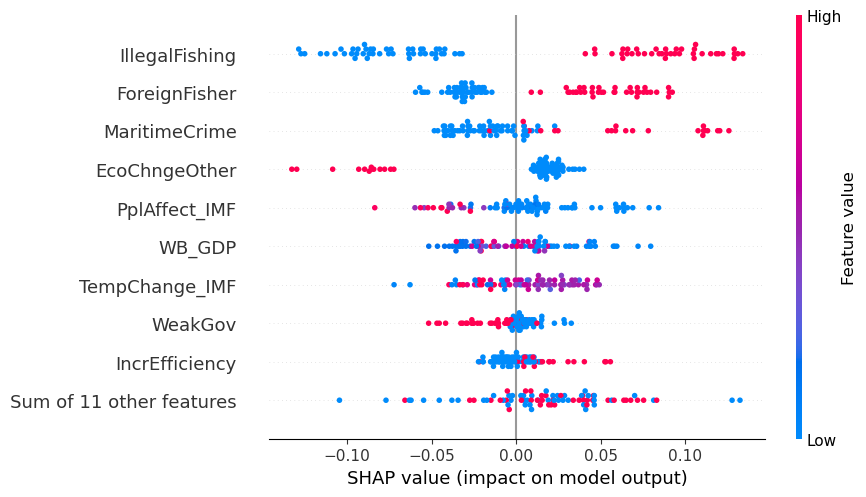

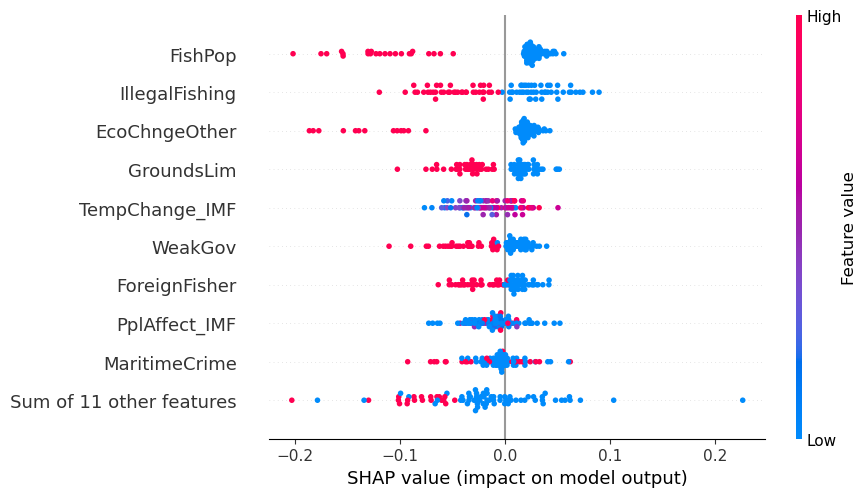

In [33]:
# Horn of Africa: Feature importance for each class (violence score = 1, 2, 3)
shap.plots.beeswarm(ha_shap_values[..., 0])
shap.plots.beeswarm(ha_shap_values[..., 1])
shap.plots.beeswarm(ha_shap_values[..., 2])

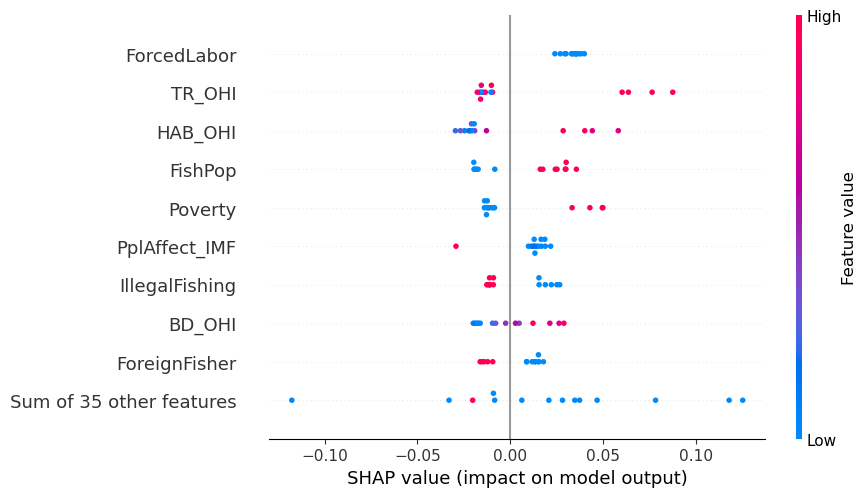

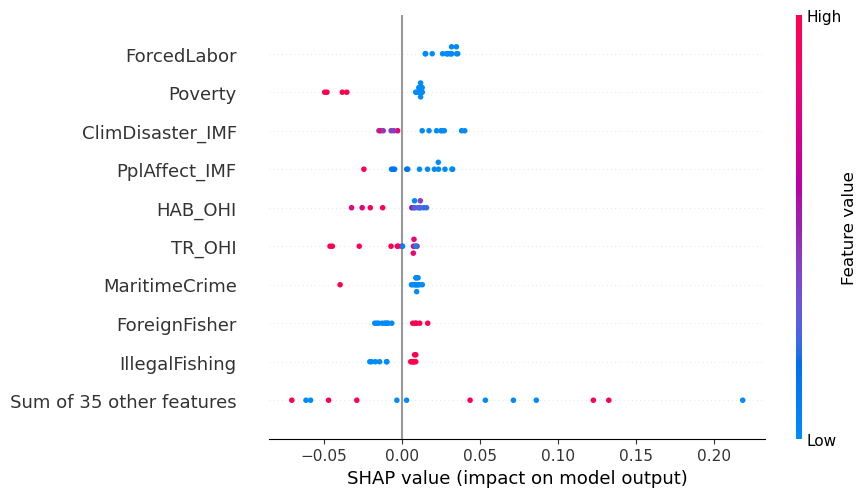

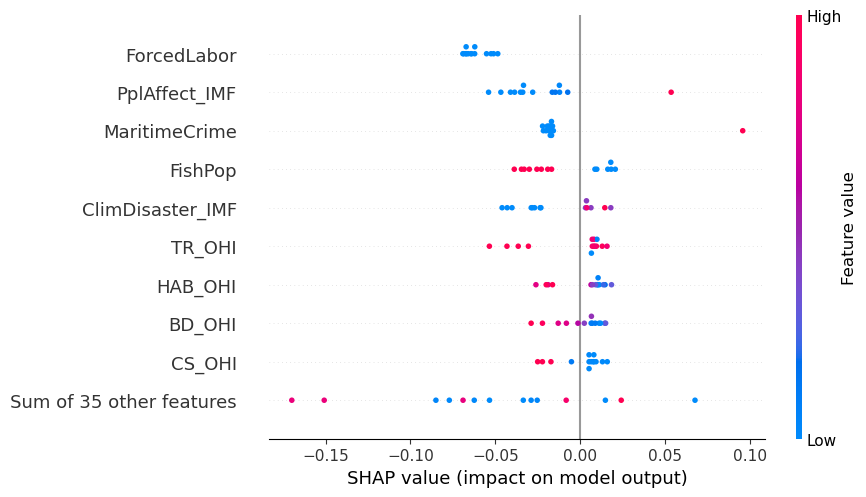

In [32]:
# Oceania: Feature importance for each class (violence score = 1, 2, 3)
shap.plots.beeswarm(oc_shap_values[..., 0])
shap.plots.beeswarm(oc_shap_values[..., 1])
shap.plots.beeswarm(oc_shap_values[..., 2])

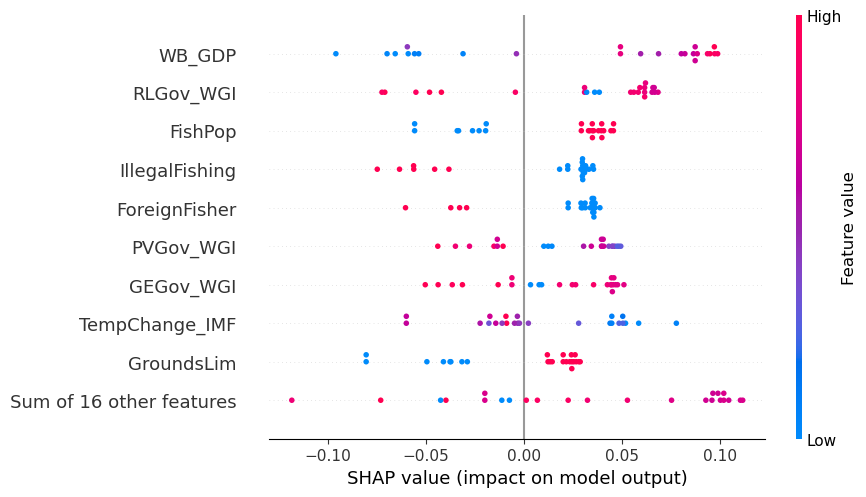

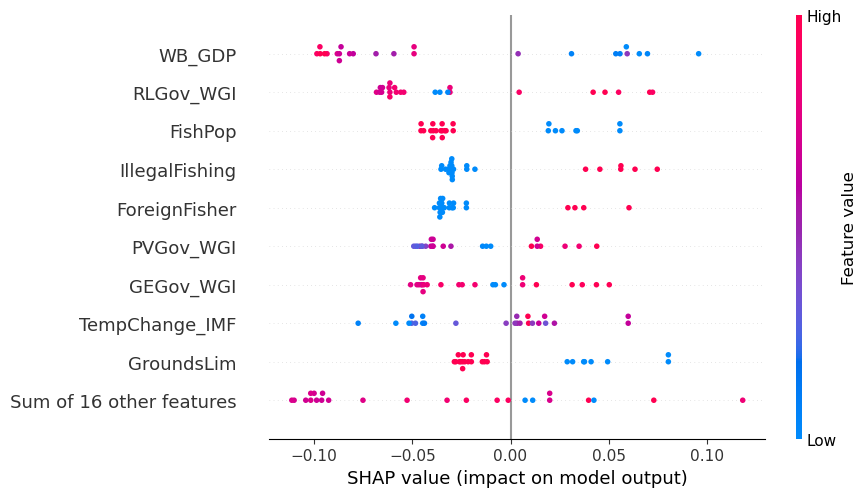

In [31]:
# Arctic: Feature importance for each class (violence score = 1, 2)
shap.plots.beeswarm(ar_shap_values[..., 0])
shap.plots.beeswarm(ar_shap_values[..., 1])

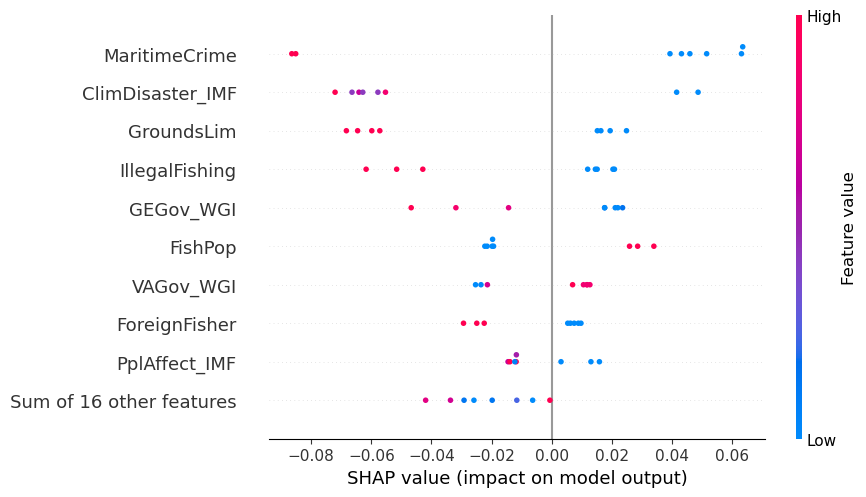

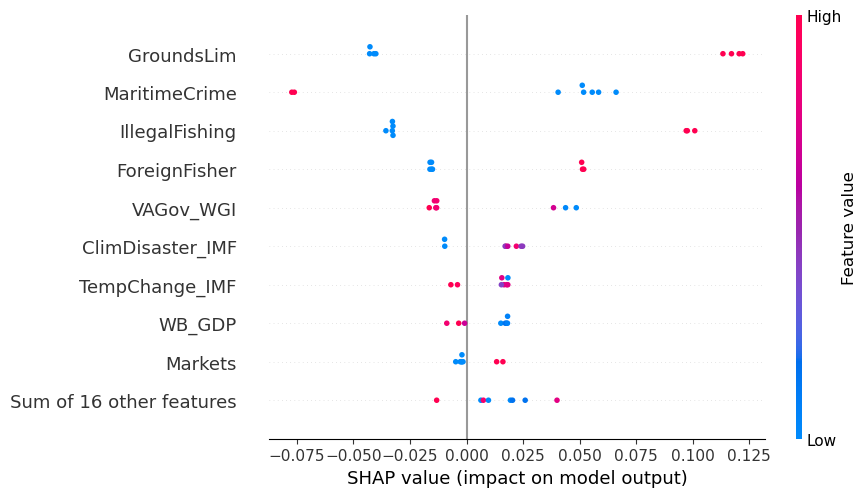

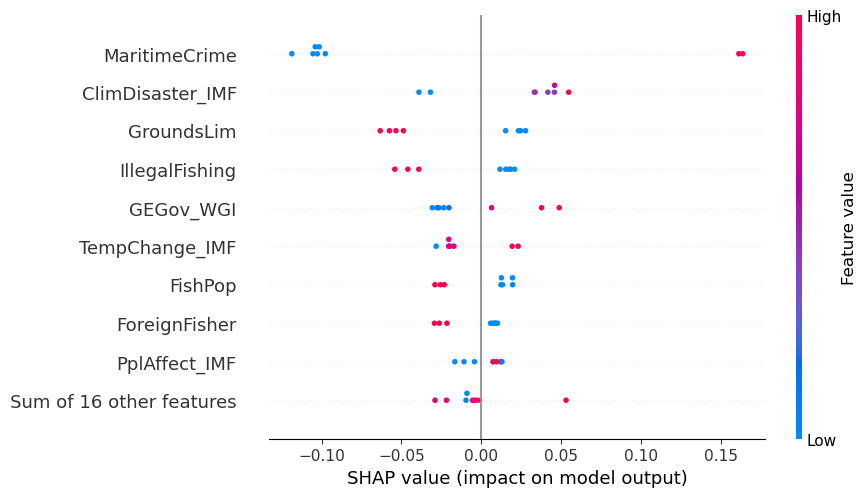

In [34]:
# South America: Feature importance for each class (violence score = 1, 2, 3)
shap.plots.beeswarm(sa_shap_values[..., 0])
shap.plots.beeswarm(sa_shap_values[..., 1])
shap.plots.beeswarm(sa_shap_values[..., 2])

In [ ]:
#Oceania Overall Feature Importance Ranking
importance = pd.DataFrame({
    "Feature": ocX_train.columns,
    "MeanAbsSHAP": np.abs(oc_shap_values.values).mean(axis=(0,2))
}).sort_values("MeanAbsSHAP",ascending=False)

print(importance)

                       Feature  MeanAbsSHAP
15                 ForcedLabor     0.041220
39               PplAffect_IMF     0.021174
31                      TR_OHI     0.020600
24                     HAB_OHI     0.018515
1                      FishPop     0.016079
13               MaritimeCrime     0.015925
38            ClimDisaster_IMF     0.015440
9                      Poverty     0.014383
18                      BD_OHI     0.011518
5               IllegalFishing     0.010061
26                   Total_OHI     0.009740
4                ForeignFisher     0.008984
20                      CS_OHI     0.008874
0                      WeakGov     0.008162
16                      WB_GDP     0.007386
35                   RGGov_WGI     0.006801
42  active_hours_previous_year     0.006281
25                     ICO_OHI     0.006209
12                    StratLoc     0.006063
23                     FOO_OHI     0.006051
21                      CW_OHI     0.005959
28                     MAR_OHI  